# Employee Attrition Analysis and Prediction

## Business Context

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They have the following question: what’s likely to make the employee leave the company?

The goal in this project is to build a predictive model that identifies employees at risk of leaving so HR can intervene proactively.

If the model predicts employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

## Executive Summary

Salifort Motors’ HR department seeks to better understand why employees leave the company and how attrition risk can be predicted using available workforce data.

In this project, I analyzed approximately **15,000 employee records** containing information about job satisfaction, workload, tenure, performance evaluations, promotions, and department affiliation. The analysis aimed to identify key drivers of employee turnover and to build predictive models capable of identifying employees at risk of leaving.

Initial exploratory analysis revealed several important patterns. Employees handling **a high number of projects** and working **long monthly hours** showed significantly higher attrition rates. Additionally, employees with **lower satisfaction scores** were substantially more likely to leave the company.

To predict employee attrition, I implemented multiple machine learning models:
- Logistic Regression as a baseline model
- Decision Tree
- Random Forest

After hyperparameter tuning and cross-validation, the Random Forest model achieved the best performance, with approximately:
- **Accuracy: 96.1%**
- **Precision: 87.4%**
- **Recall: 90.3%**
- **F1 score: 88.6%**
- **ROC-AUC: 93.8%**

Feature importance analysis consistently identified the following variables as the strongest predictors of attrition:
- Employee performance evaluations
- Project workload
- Tenure at the company
- Overwork conditions (engineered feature indicating >175 monthly hours)

These findings suggest that **workload and project burden are key contributors to employee attrition**.

Based on the analysis, several potential retention strategies emerge:
- Limit the number of projects assigned to individual employees
- Monitor employees consistently working long hours
- Identify low-satisfaction employees earlier for intervention
- Evaluate promotion pathways for longer-tenured employees

By identifying employees at risk of leaving and understanding the factors driving attrition, Salifort Motors can take proactive steps to improve retention and reduce the costs associated with employee turnover.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

import pickle

pd.set_option('display.max_columns', None)

## Dataset Overview

Source: [kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv)

Size: ~15k rows, 10 column

Variables: 

Variable  |Description |
-----|-----| 
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary level category

### Load Dataset

I begin by loading the dataset and performing a quick inspection of the data structure. This helps verify that the dataset loaded correctly and allows us to understand the basic format of the variables before starting exploratory data analysis (EDA).

> To run this notebook locally, place the source CSV in `../data/`.

In [2]:
df0 = pd.read_csv("../data/HR_comma_sep.csv")
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Problem Framing

Employee turnover is costly for organizations due to recruitment expenses, onboarding time, and lost productivity. Understanding the factors that contribute to employee attrition can help organizations take proactive steps to improve retention.

The goal of this project is to identify key drivers of employee turnover at Salifort Motors and build predictive models capable of identifying employees who may be at risk of leaving.

More specifically, the objectives are:

1. Explore employee data to identify patterns associated with attrition.
2. Build predictive models that classify whether an employee will leave the company.
3. Interpret model results to determine which factors most strongly influence attrition.
4. Translate the findings into actionable recommendations for improving employee retention.

The target variable for this analysis is **`left`**, a binary variable indicating whether an employee stayed (0) or left (1).

## Data Exploration

Before building predictive models, I first explore the dataset to understand its structure, detect potential data quality issues, and identify patterns related to employee attrition.

This step includes checking for missing values, duplicate records, and exploring key variable distributions that may influence whether employees leave the company.

In [3]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


The summary shows that employees work an average of about **201 hours per month** and typically contribute to **around 3–4 projects**. Job satisfaction ranges from 0 to 1 with a mean of approximately **0.61**, suggesting moderate overall satisfaction among employees.

### Rename Columns

As part of data cleaning, column names are standardized to follow the **snake_case** naming convention for consistency and readability.

In [5]:
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check Missing Values

In [7]:
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

There are no missing values in the data.

### Check Duplicates

In [8]:
df0.duplicated().sum()

3008

The dataset contains **3,008 duplicate rows**. Since the dataset does not include a unique employee identifier, it is unclear whether these represent true duplicates or different employees with identical attributes.

To prevent repeated observations from biasing the analysis, duplicate rows are removed. However, in a real HR dataset, this step should be validated using employee IDs before removing records.

In [9]:
df1 = df0.drop_duplicates(keep='first')

### Check Outliers

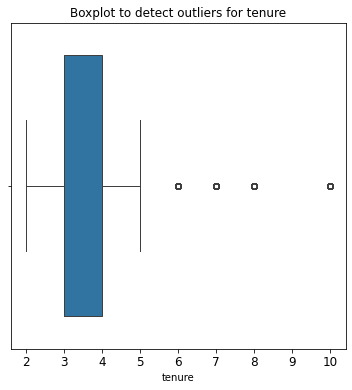

In [10]:
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df1['tenure'])
plt.show()

The boxplot suggests that several observations in the **tenure** variable fall outside the typical range of values. These potential outliers represent employees with unusually long tenure. Rather than removing them immediately, I quantify how many observations fall outside the standard interquartile range (IQR) limits.

In [11]:
# Determine the number of rows containing outliers 

# Compute the 25th and 75th percentile values in `tenure`
percentile25 = df1['tenure'].quantile(0.25)
percentile75 = df1['tenure'].quantile(0.75)

# Define the upper limit and lower limit for non-outlier values in `tenure`
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Identify subset of data containing outliers in `tenure`
outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]

print("Number of rows in the data containing outliers in `tenure`:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data containing outliers in `tenure`: 824


In [12]:
# Numbers of people who left vs. stayed
print(df1['left'].value_counts())
print()

# Percentages of people who left vs. stayed
print(df1['left'].value_counts(normalize=True))

left
0    10000
1     1991
Name: count, dtype: int64

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


Approximately **16.6% of employees left the company**, indicating a moderately imbalanced dataset. This imbalance will be considered when evaluating model performance to ensure the model does not simply predict the majority class.

## Exploratory Visual Analysis

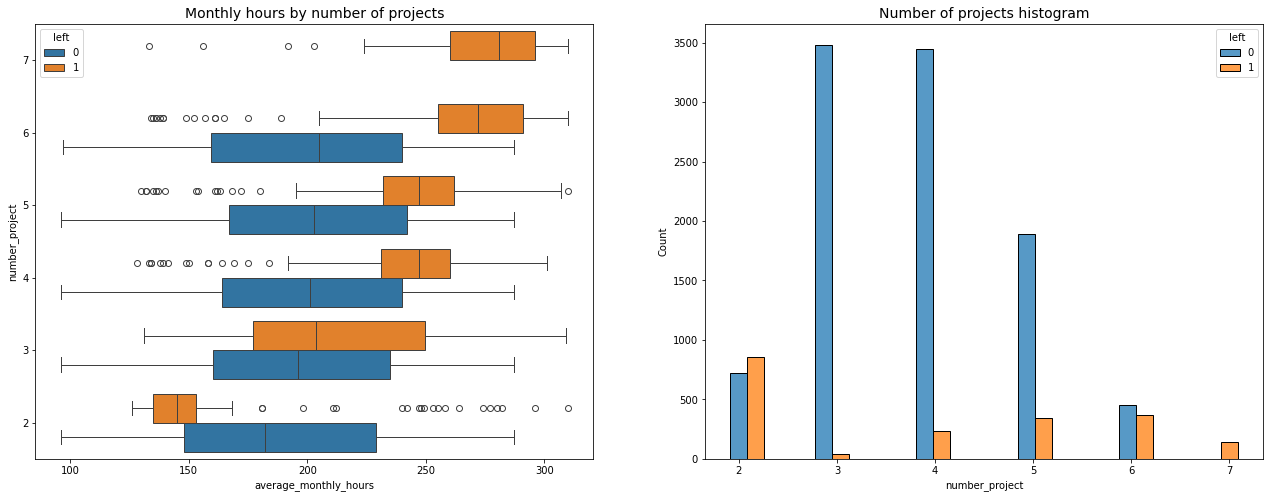

In [13]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Boxplot showing `average_monthly_hours` distributions for `number_project`, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

# Histogram showing distribution of `number_project`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

plt.show()

The plots suggest that employees who left fall into two distinct patterns:

1. Some employees worked significantly fewer hours than peers with the same number of projects.
2. Another group worked substantially more hours than their peers.

Employees working on **six or seven projects** appear to have the highest monthly working hours (approximately 255–295 hours). Notably, all employees with seven projects left the company.

These patterns suggest that both **under-utilization and excessive workload** may be associated with employee attrition.

In [14]:
# Value counts of stayed/left for employees with 7 projects
df1[df1['number_project']==7]['left'].value_counts()

left
1    145
Name: count, dtype: int64

This confirms that all employees with 7 projects did leave. 

Assuming a standard 40-hour work week and two weeks of vacation per year, the typical monthly workload would be approximately `= 50 weeks * 40 hours per week / 12 months =` **166.67 hours per month**.

Most employees in this dataset appear to work significantly more than this level, suggesting that long working hours may be a contributing factor to employee dissatisfaction and attrition.

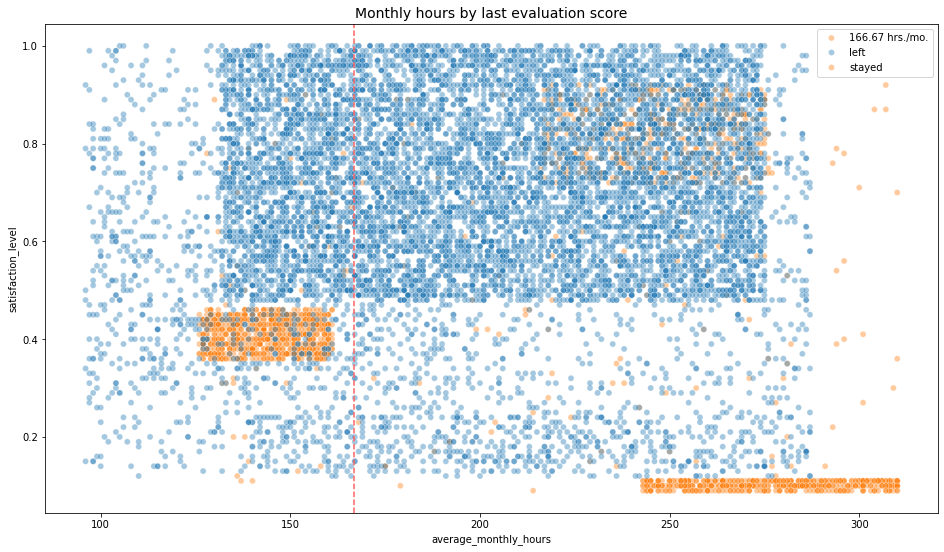

In [15]:
# Scatterplot of `average_monthly_hours` versus `satisfaction_level`, comparing employees who stayed versus those who left
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

The scatterplot above shows that there was a sizeable group of employees who worked ~240&ndash;315 hours per month. 315 hours per month is over 75 hours per week for a whole year. It's likely this is related to their satisfaction levels being close to zero. 

The plot also shows another group of employees who left despite working closer to typical working hours. However, their satisfaction levels were relatively low (around 0.4), suggesting that lower satisfaction may also be associated with attrition even when workload is not unusually high.

Finally, there is a group who worked ~210&ndash;280 hours per month, and they had satisfaction levels ranging ~0.7&ndash;0.9. 

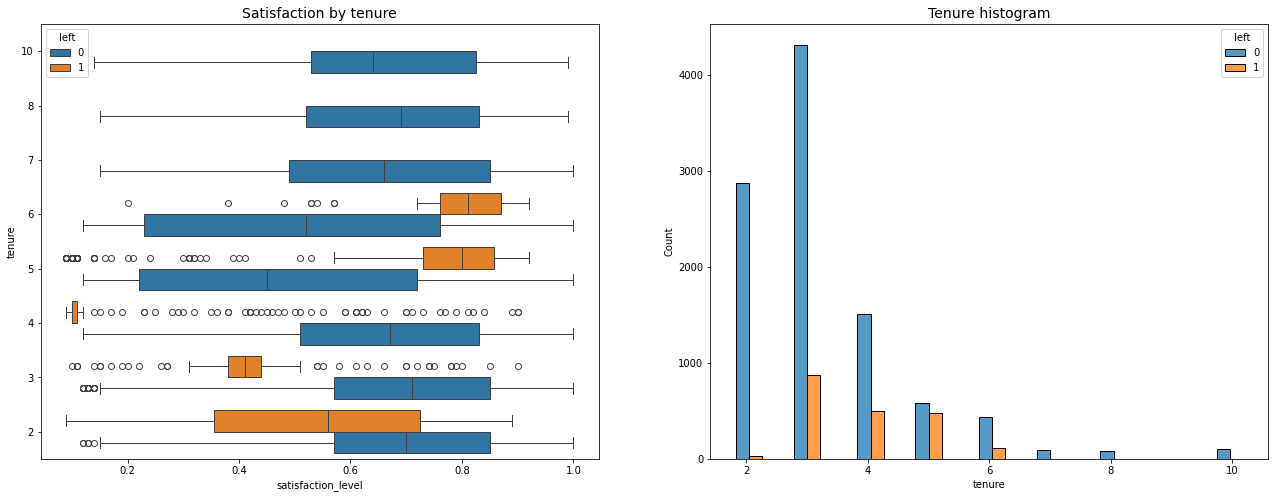

In [16]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Boxplot showing distributions of `satisfaction_level` by tenure, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by tenure', fontsize='14')

# Histogram showing distribution of `tenure`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['tenure']
tenure_left = df1[df1['left']==1]['tenure']
sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure histogram', fontsize='14')

plt.show();

Several observations emerge from this plot:
- Employees who left fall into two general categories: dissatisfied employees with shorter tenures and very satisfied employees with medium-length tenures.
- Four-year employees who left seem to have an unusually low satisfaction level. It's worth investigating changes to company policy that might have affected people specifically at the four-year mark, if possible. 
- The longest-tenured employees didn't leave. Their satisfaction levels aligned with those of newer employees who stayed. 
- The histogram shows that there are relatively few longer-tenured employees. It's possible that they're the higher-ranking, higher-paid employees.

In [17]:
# Calculate mean and median satisfaction scores of employees who left and those who stayed
df1.groupby('left')['satisfaction_level'].agg(['mean', 'median'])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


As expected, the mean and median satisfaction scores of employees who left are lower than those of employees who stayed. Interestingly, among employees who stayed, the mean satisfaction score appears to be slightly below the median score. This indicates that satisfaction levels among those who stayed might be skewed to the left. 

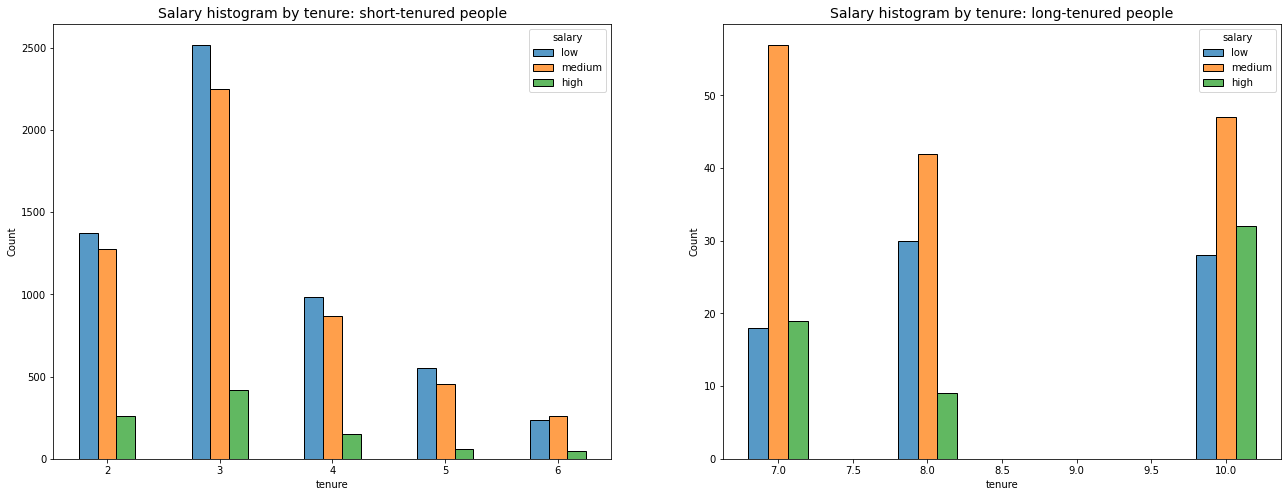

In [18]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Define short-tenured and long-tenured employees
tenure_short = df1[df1['tenure'] < 7]
tenure_long = df1[df1['tenure'] > 6]

# Short-tenured histogram
sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

# Long-tenured histogram
sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14');

The plots above show that long-tenured employees were not disproportionately comprised of higher-paid employees. 

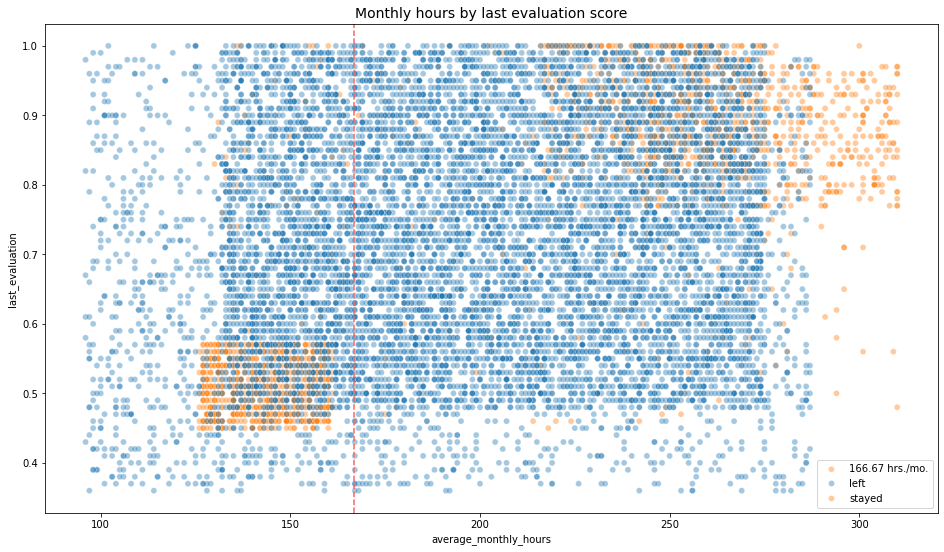

In [19]:
# Scatterplot of `average_monthly_hours` versus `last_evaluation`
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

The following observations can be made from the scatterplot above:
- The scatterplot indicates two groups of employees who left: overworked employees who performed very well and employees who worked slightly under the nominal monthly average of 166.67 hours with lower evaluation scores. 
- There seems to be a correlation between hours worked and evaluation score. 
- There isn't a high percentage of employees in the upper left quadrant of this plot; but working long hours doesn't guarantee a good evaluation score.
- Most of the employees in this company work well over 167 hours per month.

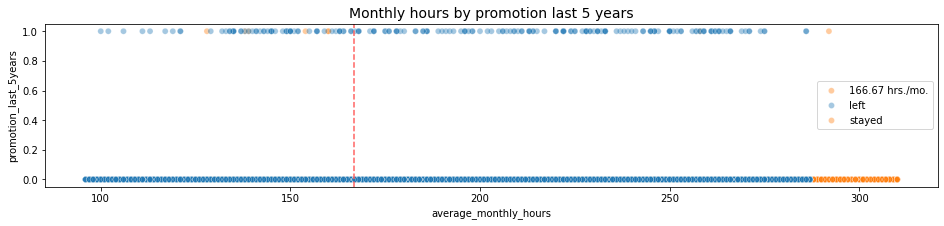

In [20]:
# Plot to examine relationship between `average_monthly_hours` and `promotion_last_5years`
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14');

The plot above shows the following:
- Very few employees who were promoted in the last five years left
- Very few employees who worked the most hours were promoted
- All of the employees who left were working the longest hours  

In [21]:
# Display counts for each department
df1["department"].value_counts()

department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

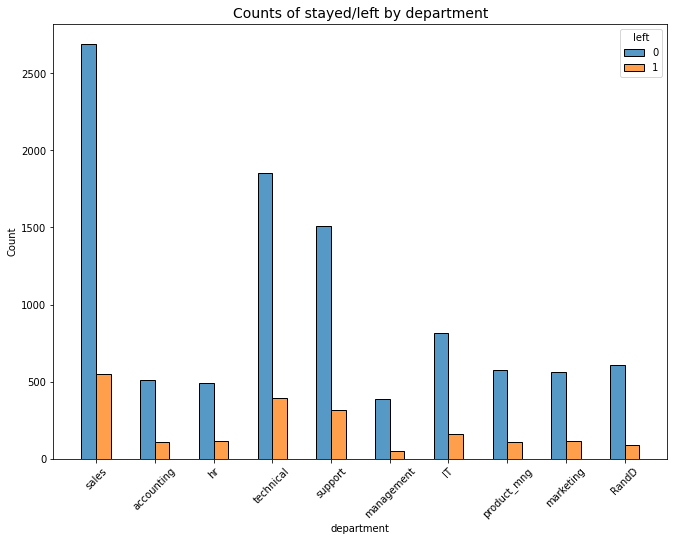

In [22]:
# Stacked histogram to compare department distribution of employees who left to that of employees who didn't
plt.figure(figsize=(11,8))
sns.histplot(data=df1, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of stayed/left by department', fontsize=14);


There doesn't seem to be any department that differs significantly in its proportion of employees who left to those who stayed. 

Lastly, I could check for strong correlations between variables in the data.

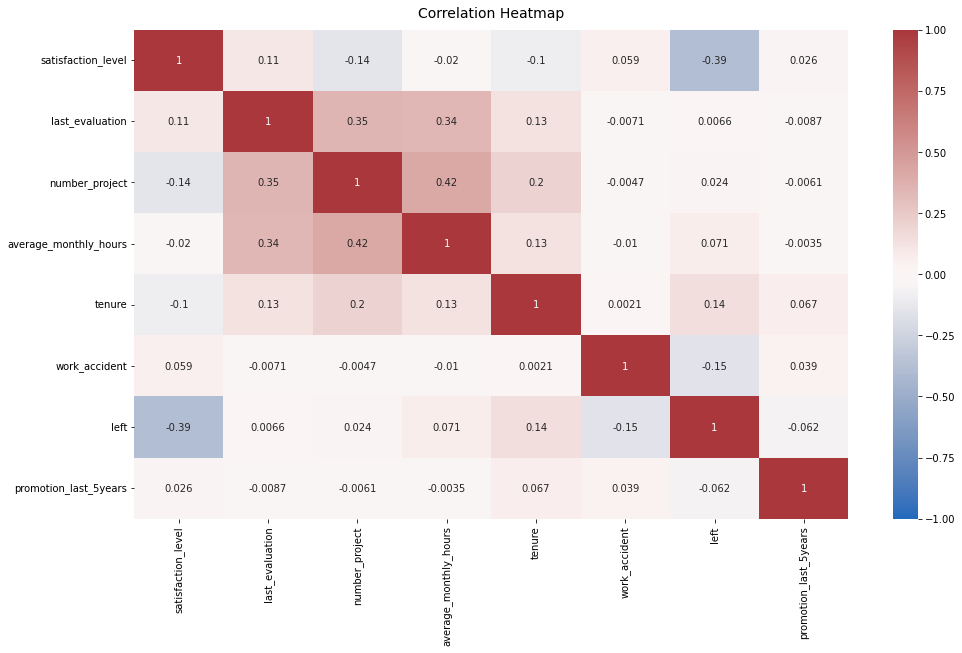

In [23]:
# A correlation heatmap
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df0.corr(numeric_only=True), vmin=-1, vmax=1, annot=True,
                      cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

The correlation heatmap indicates **moderate positive** relationships between **number of projects**, **monthly working hours**, and **evaluation scores**. Employee attrition shows the strongest negative correlation with satisfaction level, reinforcing the earlier observation that lower satisfaction is associated with employees leaving the company.

### EDA Findings

The exploratory analysis suggests several factors associated with employee attrition:
- Employees who leave tend to have **lower job satisfaction levels**.
- Higher workloads appear to be associated with attrition. Many employees who left were working **significantly more than the typical monthly workload**.
- Employees handling **six or more projects** show a particularly high attrition rate.
- Promotions appear to be relatively rare and may play a role in employee retention.
- Attrition rates appear relatively similar across departments.

Overall, the results suggest that **workload balance and employee satisfaction** may be important factors influencing employee turnover.

## Modeling

The goal is to predict employee attrition based on factors such as workload, satisfaction level, tenure, and department. This involves binary classification, and the outcome variable `left` can be either 1 (indicating employee left) or 0 (indicating employee didn't leave). Logistic regression is used as a baseline classification model.

### Baseline Model: Logistic Regression

Before splitting the data, the non-numeric variables must be encoded so they can be used by the model. The dataset contains two such variables: `department` and `salary`.

- `department` is a nominal categorical variable, so it is converted into dummy (one-hot encoded) variables for modeling.

- `salary` is also categorical but ordinal, with a natural ranking (`low`, `medium`, `high`). Because the categories have an inherent order, the variable is encoded as numeric levels ranging from 0–2 rather than using dummy variables.

In [24]:
df_enc = df1.copy()

# Encode the `salary` column as an ordinal numeric category
df_enc['salary'] = (
    df_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Dummy encode the `department` column
df_enc = pd.get_dummies(df_enc, drop_first=False)

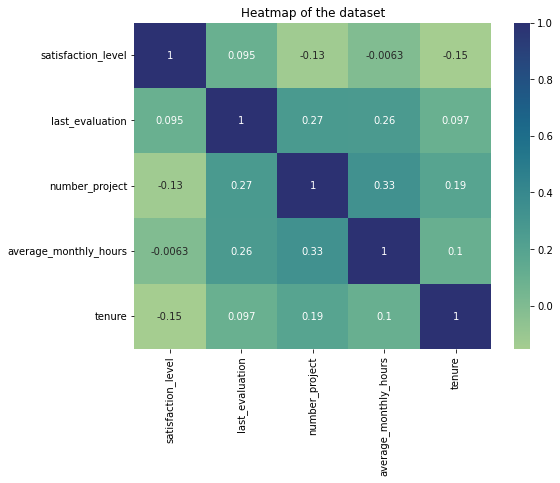

In [25]:
# A heatmap to visualize how correlated variables are
plt.figure(figsize=(8, 6))
sns.heatmap(df_enc[['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure']]
            .corr(), annot=True, cmap="crest")
plt.title('Heatmap of the dataset')
plt.show()

The heatmap indicates moderate correlations among several predictors. In particular, number of projects, average monthly hours, and last evaluation score show positive relationships with one another. These relationships suggest that employees who work on more projects tend to work longer hours and receive higher evaluations.

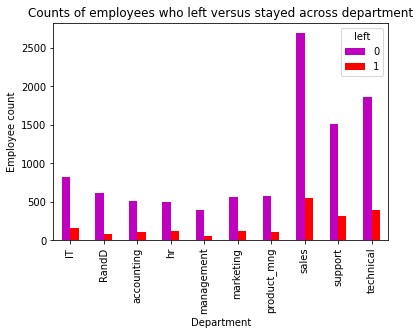

In [26]:
# A stacked bart plot to visualize number of employees across department, comparing those who left with those who didn't
pd.crosstab(df1['department'], df1['left']).plot(kind ='bar',color='mr')
plt.title('Counts of employees who left versus stayed across department')
plt.ylabel('Employee count')
plt.xlabel('Department')
plt.show()

Because logistic regression can be sensitive to extreme values, outliers in the **tenure** variable are removed before training the model.

In [27]:
# Selecting rows without outliers in `tenure`
df_logreg = df_enc[(df_enc['tenure'] >= lower_limit) & (df_enc['tenure'] <= upper_limit)]

In [28]:
y = df_logreg['left']

In [29]:
# Selecting features to use in the model
X = df_logreg.drop('left', axis=1)

In [30]:
# Spliting data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [31]:
# Constructing a logistic regression model and fit it to the training dataset
log_clf = LogisticRegression(random_state=42, max_iter=500).fit(X_train, y_train)

In [32]:
# Using the logistic regression model to get predictions on the test set
y_pred = log_clf.predict(X_test)

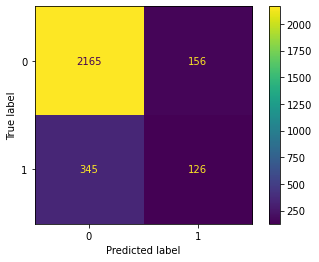

In [33]:
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, 
                                  display_labels=log_clf.classes_)
log_disp.plot(values_format='')
plt.show()

The confusion matrix shows the distribution of correct and incorrect predictions.

- True negatives: employees correctly predicted to stay  
- False positives: employees incorrectly predicted to leave  
- False negatives: employees who left but were predicted to stay  
- True positives: employees correctly predicted to leave

In [34]:
df_logreg['left'].value_counts(normalize=True)

left
0    0.831468
1    0.168532
Name: proportion, dtype: float64

The target variable shows an approximate **83%–17% class distribution**. So the data is not perfectly balanced, but it is not too imbalanced.

In [35]:
# Creating classification report for logistic regression model
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))

                           precision    recall  f1-score   support

Predicted would not leave       0.86      0.93      0.90      2321
    Predicted would leave       0.45      0.27      0.33       471

                 accuracy                           0.82      2792
                macro avg       0.65      0.60      0.62      2792
             weighted avg       0.79      0.82      0.80      2792



The classification report above shows that the logistic regression model achieved a precision of 79%, recall of 82%, f1 score of 80% (all weighted averages), and accuracy of 82%. 

While the overall model accuracy is 82%, performance for predicting employees who leave is weaker. The recall for this class is relatively low, meaning the model misses a substantial number of employees who actually leave. This suggests that additional modeling approaches may improve prediction performance.

### Tree-Based Models

While logistic regression provides a useful baseline, tree-based models can capture nonlinear relationships and interactions between variables. 

In this section, I evaluate two tree-based approaches:

- **Decision Tree**
- **Random Forest**

I used several evaluation metrics to assess model performance, including accuracy, precision, recall, F1 score, and ROC-AUC. Hyperparameters are tuned using **GridSearchCV with cross-validation**, optimizing primarily for **ROC-AUC**, since the goal is to distinguish employees likely to leave from those who stay. This makes it particularly useful when evaluating classification models where:

- Class distributions may not be perfectly balanced
- Different classification thresholds may be used depending on business needs

By optimizing ROC-AUC during cross-validation, the model is encouraged to maximize its overall ability to separate employees likely to leave from those likely to stay.

In [36]:
# Isolating the outcome variable
y = df_enc['left']

In [37]:
# Selecting the features
X = df_enc.drop('left', axis=1)

In [38]:
# Spliting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

#### Decision Tree Model (Round 1)

A decision tree classifier is trained using cross-validated hyperparameter tuning. 

In [39]:
tree = DecisionTreeClassifier(random_state=0)
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

Fit the decision tree model to the training data.

In [40]:
%%time
tree1.fit(X_train, y_train)

CPU times: user 1.91 s, sys: 12.6 ms, total: 1.92 s
Wall time: 1.91 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='roc_auc',
             scoring={'precision', 'f1', 'roc_auc', 'recall', 'accuracy'})

In [41]:
# Checking best parameters
tree1.best_params_

{'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}

The best hyperparameters found through cross-validation suggest a relatively shallow tree. This helps prevent overfitting while maintaining strong predictive performance.

In [42]:
# Checking best AUC score on CV
tree1.best_score_

0.969819392792457

This AUC score indicates strong discriminatory power, suggesting that the model can effectively distinguish between employees who stay and those who leave.

In [43]:
def make_results(model_name, model_object, metric):
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    return pd.DataFrame({
        'model': [model_name],
        'precision': [best_estimator_results.mean_test_precision],
        'recall': [best_estimator_results.mean_test_recall],
        'F1': [best_estimator_results.mean_test_f1],
        'accuracy': [best_estimator_results.mean_test_accuracy],
        'auc': [best_estimator_results.mean_test_roc_auc]
    })

In [44]:
tree1_cv_results = make_results('decision tree cv', tree1, 'auc')
tree1_cv_results

,model,precision,recall,F1,accuracy,auc
0,decision tree cv,0.914552,0.916949,0.915707,0.971978,0.969819


All of these scores from the decision tree model are strong indicators of good model performance.

#### Random Forest Model (Round 1)

Random forests extend decision trees by building an ensemble of trees trained on random subsets of the data and features.

This approach typically:

- reduces overfitting
- improves generalization
- captures complex feature interactions

Hyperparameters are tuned using GridSearchCV with cross-validation.

In [45]:
rf = RandomForestClassifier(random_state=0)
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

Fit the random forest model to the training data.

In [46]:
%%time
rf1.fit(X_train, y_train)

CPU times: user 12min 27s, sys: 209 ms, total: 12min 27s
Wall time: 12min 27s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [3, 5, None], 'max_features': [1.0],
                         'max_samples': [0.7, 1.0],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [300, 500]},
             refit='roc_auc',
             scoring={'precision', 'f1', 'roc_auc', 'recall', 'accuracy'})

In [47]:
# Saving and reading the model
path = '../models/'

def write_pickle(path, model_object, save_as:str):
    os.makedirs(path, exist_ok=True)
    with open(path + save_as + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)
        
def read_pickle(path, saved_model_name:str):
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

    return model

In [48]:
write_pickle(path, rf1, 'rf_baseline')

In [49]:
rf1 = read_pickle(path, 'rf_baseline')

In [50]:
rf1.best_score_

0.9804250949807172

In [51]:
rf1.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 500}

In [52]:
rf1_cv_results = make_results('random forest cv', rf1, 'auc')
print(tree1_cv_results)
print(rf1_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.914552  0.916949  0.915707  0.971978  0.969819
              model  precision    recall        F1  accuracy       auc
0  random forest cv   0.950023  0.915614  0.932467  0.977983  0.980425


The random forest model slightly outperforms the single decision tree across most evaluation metrics, particularly in ROC-AUC and accuracy. This improvement is expected, as ensemble models generally provide better generalization by aggregating predictions across multiple trees.

In [53]:
def get_scores(model_name:str, model, X_test_data, y_test_data):
    preds = model.best_estimator_.predict(X_test_data)

    return pd.DataFrame({
        'model': [model_name],
        'precision': [precision_score(y_test_data, preds)], 
        'recall': [recall_score(y_test_data, preds)],
        'f1': [f1_score(y_test_data, preds)],
        'accuracy': [accuracy_score(y_test_data, preds)],
        'AUC': [roc_auc_score(y_test_data, preds)]
    })

Now use the best performing model to predict on the test set.

In [54]:
rf1_test_scores = get_scores('random forest1 test', rf1, X_test, y_test)
rf1_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest1 test,0.964211,0.919679,0.941418,0.980987,0.956439


The test scores are very similar to the validation scores, which is good.

## Feature Engineering

Although the initial models performed well, there is potential **data leakage** in the dataset.

In particular:

- `satisfaction_level`
- `average_monthly_hours`

may reflect information that becomes available **after an employee has already decided to leave**, which could artificially inflate model performance.

To reduce this risk and improve model interpretability:

1. `satisfaction_level` is removed.
2. A new binary feature **`overworked`** is created based on monthly working hours.

Employees working **more than 175 hours per month** are classified as overworked.

In [55]:
# Droping `satisfaction_level`
df2 = df_enc.drop('satisfaction_level', axis=1)

In [56]:
# Creating `overworked` column.
df2['overworked'] = df2['average_monthly_hours']
print('Max hours:', df2['overworked'].max())
print('Min hours:', df2['overworked'].min())

Max hours: 310
Min hours: 96


A typical full-time schedule corresponds to roughly **167 hours per month** (8 hours/day × 5 days/week × 50 weeks/year).

Using this as a reference point, employees working **more than 175 hours per month** are labeled as *overworked*.

In [57]:
# Defining `overworked` as working > 175 hrs/week
df2['overworked'] = (df2['overworked'] > 175).astype(int)

In [58]:
# Droping the `average_monthly_hours` column
df2 = df2.drop('average_monthly_hours', axis=1)

In [59]:
y = df2['left']
X = df2.drop('left', axis=1)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

## Improved Modeling

#### Decision Tree Model (Round 2)

In [61]:
tree = DecisionTreeClassifier(random_state=0)
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
tree2 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [62]:
%%time
tree2.fit(X_train, y_train)

CPU times: user 1.5 s, sys: 0 ns, total: 1.5 s
Wall time: 1.5 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='roc_auc',
             scoring={'precision', 'f1', 'roc_auc', 'recall', 'accuracy'})

In [63]:
tree2.best_params_

{'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 6}

In [64]:
tree2.best_score_

0.9586752505340426

This model performs very well, even without satisfaction levels and detailed hours worked data. 

In [65]:
tree2_cv_results = make_results('decision tree2 cv', tree2, 'auc')
print(tree1_cv_results)
print(tree2_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.914552  0.916949  0.915707  0.971978  0.969819
               model  precision    recall        F1  accuracy       auc
0  decision tree2 cv   0.856693  0.903553  0.878882  0.958523  0.958675


Some of the other scores fell. That's to be expected given fewer features were taken into account in this round of the model. Still, the scores are very good.

#### Random Forest Model (Round 2)

In [66]:
rf = RandomForestClassifier(random_state=0)
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
rf2 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [67]:
%%time
rf2.fit(X_train, y_train)

CPU times: user 9min 2s, sys: 228 ms, total: 9min 2s
Wall time: 9min 2s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [3, 5, None], 'max_features': [1.0],
                         'max_samples': [0.7, 1.0],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [300, 500]},
             refit='roc_auc',
             scoring={'precision', 'f1', 'roc_auc', 'recall', 'accuracy'})

In [68]:
write_pickle(path, rf2, 'rf_refined')

In [69]:
rf2 = read_pickle(path, 'rf_refined')

In [70]:
rf2.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

In [71]:
rf2.best_score_

0.9648100662833985

In [72]:
rf2_cv_results = make_results('random forest2 cv', rf2, 'auc')
print(tree2_cv_results)
print(rf2_cv_results)

               model  precision    recall        F1  accuracy       auc
0  decision tree2 cv   0.856693  0.903553  0.878882  0.958523  0.958675
               model  precision    recall        F1  accuracy      auc
0  random forest2 cv   0.866758  0.878754  0.872407  0.957411  0.96481


Again, the scores dropped slightly, but the random forest performs better than the decision tree if using AUC as the deciding metric. 

In [73]:
# Predictions on test data
rf2_test_scores = get_scores('random forest2 test', rf2, X_test, y_test)
rf2_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest2 test,0.870406,0.903614,0.8867,0.961641,0.938407


This seems to be a stable, well-performing final model. 

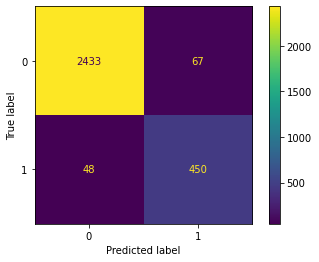

In [74]:
preds = rf2.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=rf2.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=rf2.classes_)
disp.plot(values_format='');

The model predicts more false positives than false negatives, which means that some employees may be identified as at risk of quitting or getting fired, when that's actually not the case. But this is still a strong model.

#### Decision tree splits

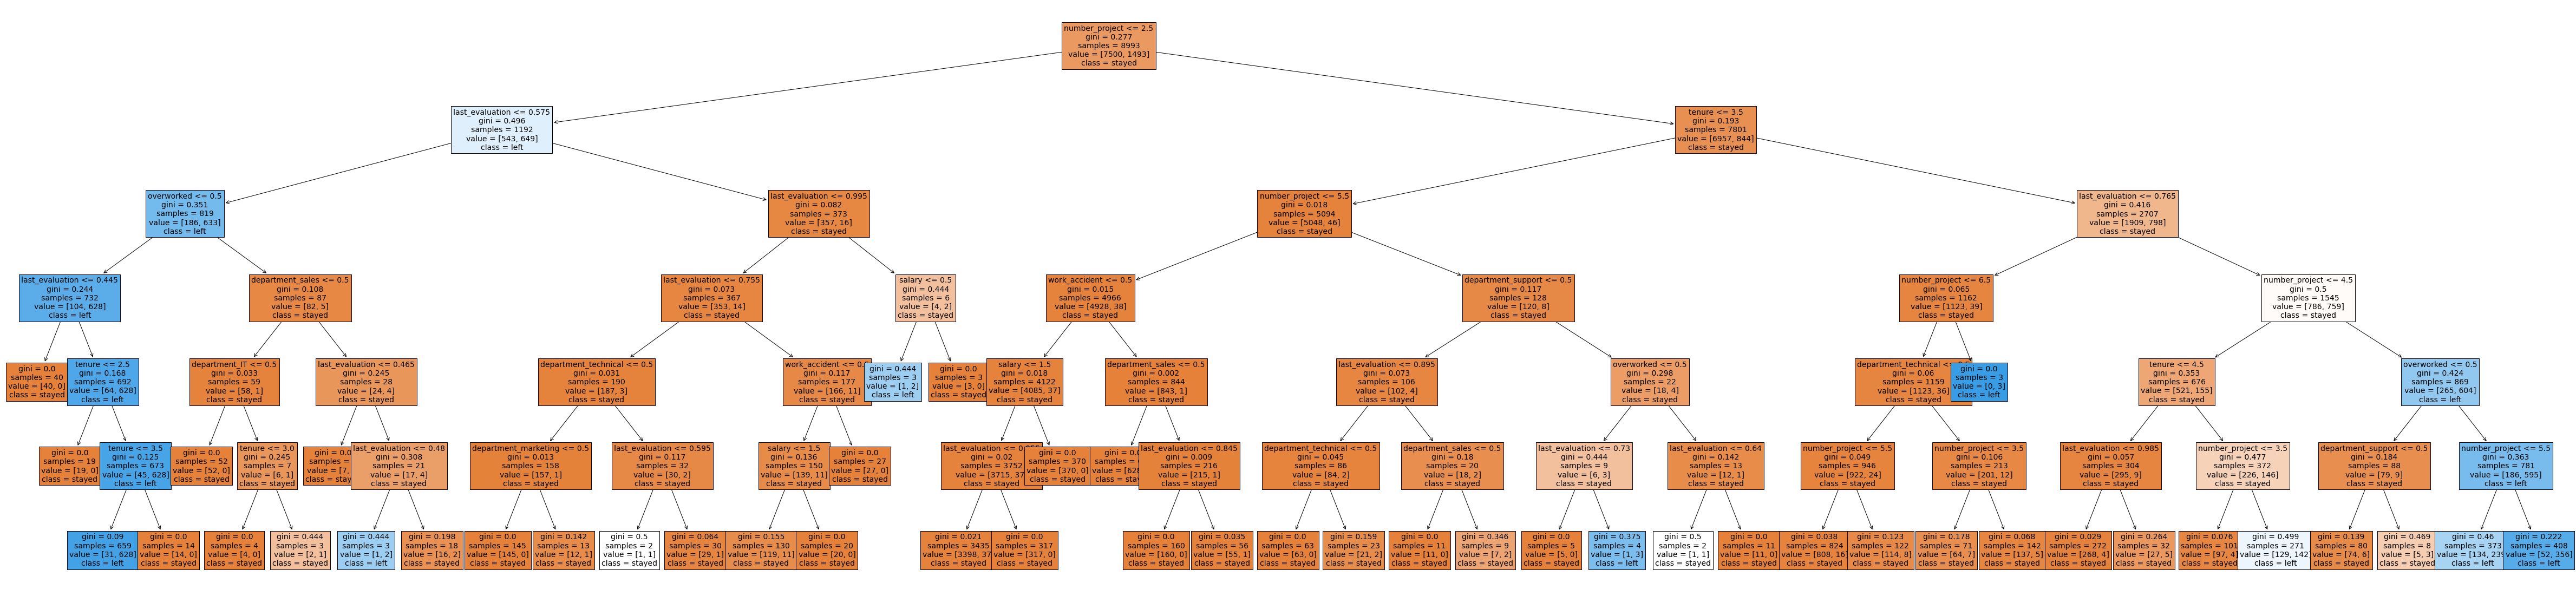

In [75]:
plt.figure(figsize=(85,20))
plot_tree(tree2.best_estimator_, max_depth=6, fontsize=14, feature_names=X.columns, 
          class_names={0:'stayed', 1:'left'}, filled=True);
plt.show()

## Model Interpretation

To better understand the drivers of employee attrition, feature importance is examined for both the decision tree and random forest models.

### Decision Tree Feature Importance

In [76]:
tree2_importances = pd.DataFrame(tree2.best_estimator_.feature_importances_, 
                                 columns=['gini_importance'], 
                                 index=X.columns
                                )
tree2_importances = tree2_importances.sort_values(by='gini_importance', ascending=False)

# Only extracting the features with importances > 0
tree2_importances = tree2_importances[tree2_importances['gini_importance'] != 0]
tree2_importances

,gini_importance
last_evaluation,0.343958
number_project,0.343385
tenure,0.215681
overworked,0.093498
department_support,0.001142
salary,0.000910
department_sales,0.000607
department_technical,0.000418
work_accident,0.000183
department_IT,0.000139


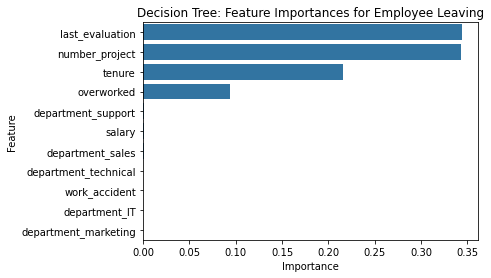

In [77]:
sns.barplot(data=tree2_importances, x="gini_importance", y=tree2_importances.index, orient='h')
plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()

The decision tree identifies the following variables as most influential:

1. `last_evaluation`
2. `number_project`
3. `tenure`
4. `overworked`

These variables appear to play the strongest role in predicting employee turnover.

### Random Forest Feature Importance

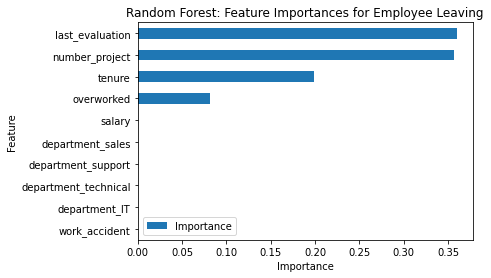

In [78]:
feat_impt = rf2.best_estimator_.feature_importances_
ind = np.argpartition(rf2.best_estimator_.feature_importances_, -10)[-10:]
feat = X.columns[ind]
feat_impt = feat_impt[ind]

y_df = pd.DataFrame({"Feature":feat,"Importance":feat_impt})
y_sort_df = y_df.sort_values("Importance")
fig = plt.figure()
ax1 = fig.add_subplot(111)

y_sort_df.plot(kind='barh',ax=ax1,x="Feature",y="Importance")

ax1.set_title("Random Forest: Feature Importances for Employee Leaving", fontsize=12)
ax1.set_ylabel("Feature")
ax1.set_xlabel("Importance")

plt.show()

The random forest model highlights a similar set of key predictors, confirming the importance of:

- Employee performance evaluations
- Project workload
- Tenure at the company
- Overwork conditions

The consistency between models strengthens confidence in these findings.

## Model Evaluation

### Logistic Regression

The logistic regression baseline achieved:

- Accuracy: 82%
- Precision: 79%
- Recall: 82%
- F1 score: 80%

However, its performance was weaker for identifying employees who left, due to class imbalance in the dataset.

### Tree-Based Models

Tree-based approaches improved performance substantially. The final Random Forest model achieved approximately:

- **Accuracy: 96.1%**
- Precision: 87.4%
- Recall: 90.3%
- F1 score: 88.6%
- ROC-AUC: 93.8%

This indicates stronger predictive performance and better class separation than the baseline model.

## Final Insights

The models suggest that **workload, project load, and tenure** are key predictors of employee attrition.

- Employees with **lower satisfaction levels** are substantially more likely to leave.
- **High monthly working hours** are associated with increased attrition risk.
- **High project load** was another strong indicator of turnover risk.
- In this dataset, employees assigned to **7 projects** all left the company.
- Tree-based models, especially Random Forest, captured attrition patterns more effectively than the logistic regression baseline.

## Recommendations

Based on the analysis, the company could consider:
- Limiting excessive project allocation for individual employees
- Monitoring employees with sustained high monthly working hours and redistributing workload where possible
- Identifying low-satisfaction employees earlier for targeted retention support
- Reviewing promotion and career progression signals for employees with longer tenure
- Using attrition-risk predictions to prioritize HR follow-up and intervention

## Next Steps

Future work could include:

- Investigating potential leakage effects by re-evaluating the role of evaluation-related variables.
- Testing additional models such as Gradient Boosting or XGBoost.
- Exploring resampling techniques to further address class imbalance.
- Conducting deeper feature engineering to capture workload dynamics more accurately.